In [1]:
import sys
sys.path.append("../data")
from acoupipe_extensions import VariableArrayConfig, random_positions, VogelHansen

from acoupipe.datasets.synthetic import DatasetSynthetic

import numpy as np
import matplotlib.pyplot as plt

/home/zaid/.conda/envs/thesis/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [7]:
from scipy import optimize, special
from scipy.integrate import quad

def VogelHansenNew(min_num_mics, max_num_mics, generator):

    #uniformly distribute H and M
    M = generator.integers(min_num_mics, max_num_mics + 1) 
    H = generator.uniform(-4,4)
    V = generator.uniform(1.5,6.5)
    

    r_max=0.5


    def F(r):
        if H<0:
            return 1/special.iv(0,np.pi*H*np.sqrt(1+0j-r*r))
        
        return special.iv(0,np.pi*H*np.sqrt(1+0j-r*r))
    
    def Freal(r):
        return F(r).real
    
    FI = quad(Freal,0,1)[0]  

    def Froot(r):
        A = FI/(M*F(r))
        r0 = np.sqrt(np.cumsum(A)).real
        return (r-r0)
    
    rz = optimize.leastsq(Froot,np.zeros(M)/M+0.01)
    rz = rz[0]
    rm = rz * r_max/rz.max() 
    n = np.arange(M)+1
    theta = np.pi*n*(1+np.sqrt(V))
    xyz = np.zeros((3,M),dtype=np.double)
    xyz[0] = rm*np.cos(theta)
    xyz[1] = rm*np.sin(theta)

    # Centering
    xyz[0] -= np.mean(xyz[0])
    xyz[1] -= np.mean(xyz[1])

    #Normalizing 
    aperture = np.max(pdist(xyz[:2].T)) #Aperture in acoupipe is defined as the maximum pairwise distance between microphones
    xyz[:2] /= aperture

    return xyz

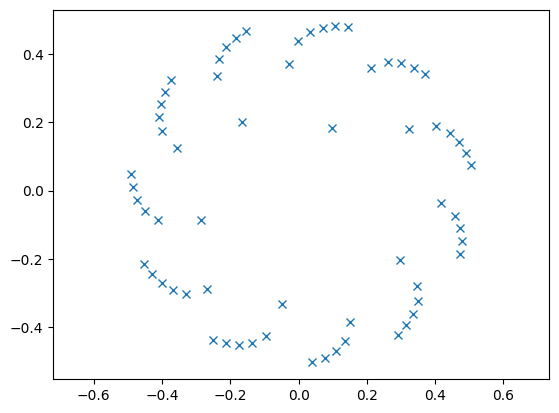

torch.Size([3, 64])


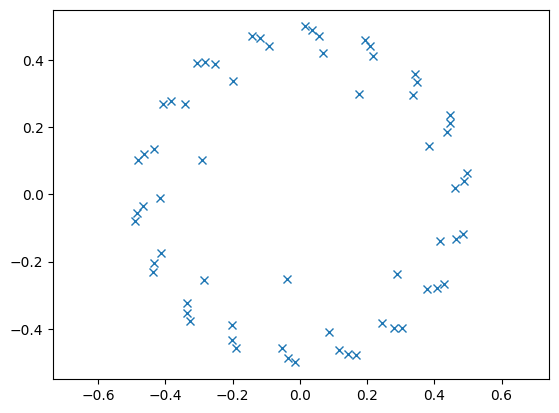

torch.Size([3, 64])


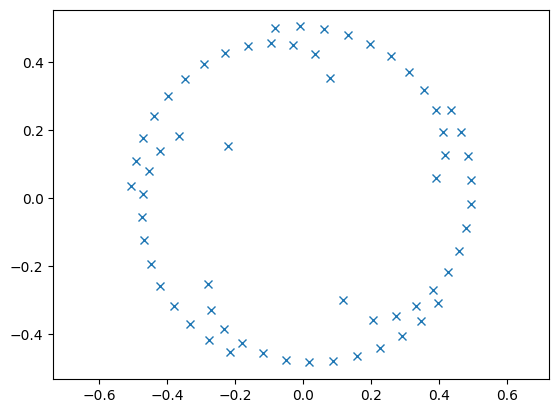

torch.Size([3, 64])


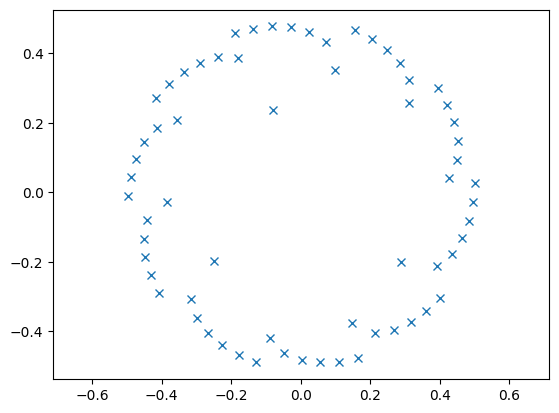

torch.Size([3, 64])


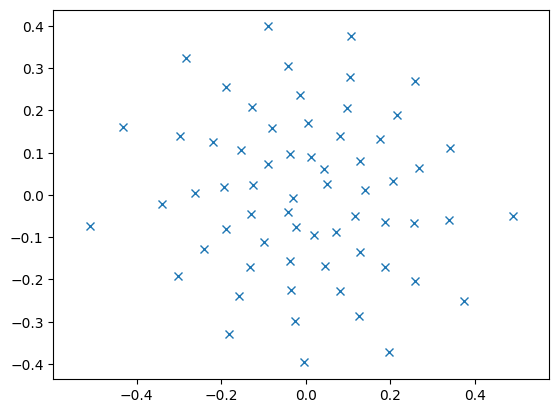

torch.Size([3, 64])


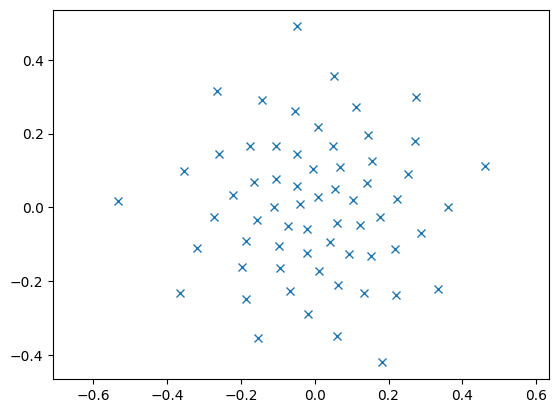

torch.Size([3, 64])


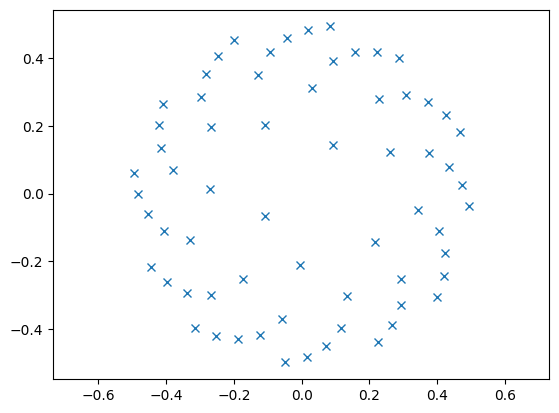

torch.Size([3, 64])


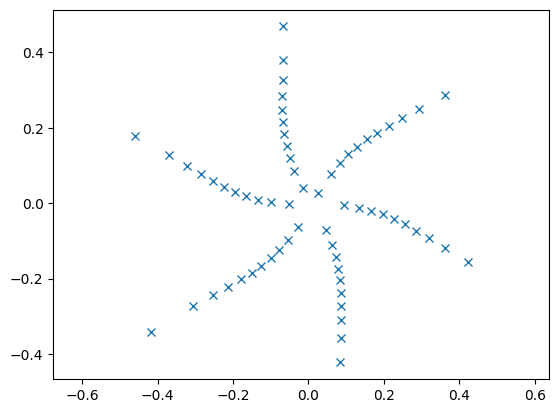

torch.Size([3, 64])


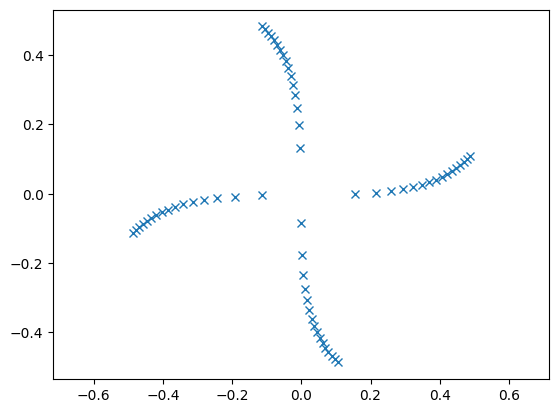

torch.Size([3, 64])


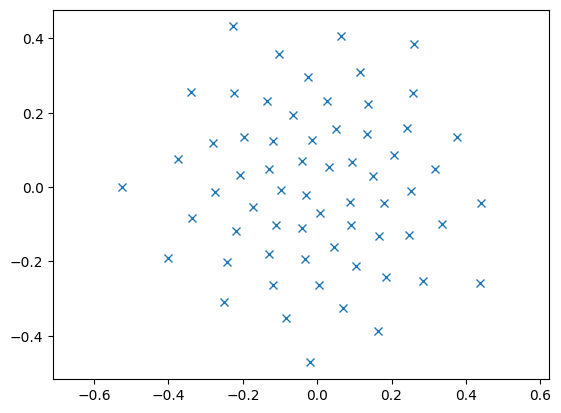

torch.Size([3, 64])


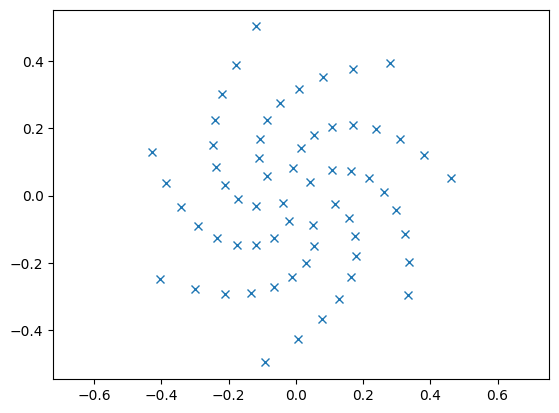

torch.Size([3, 64])


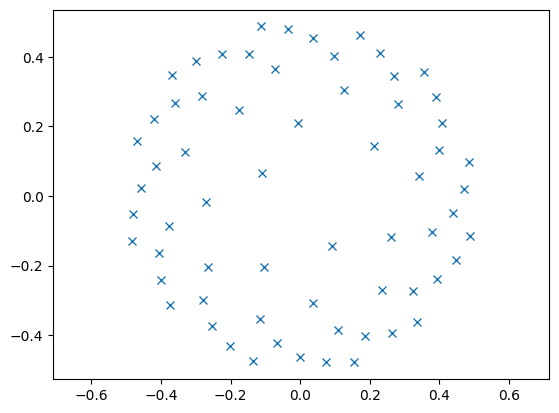

torch.Size([3, 64])


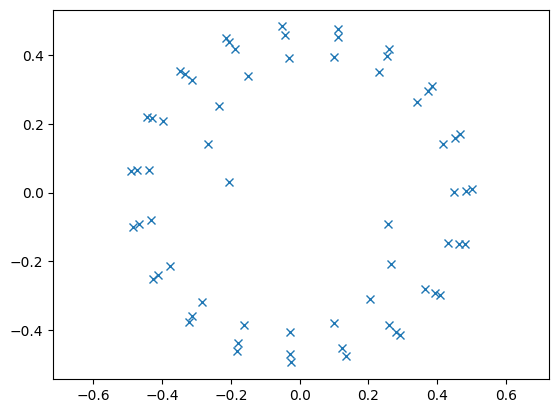

torch.Size([3, 64])


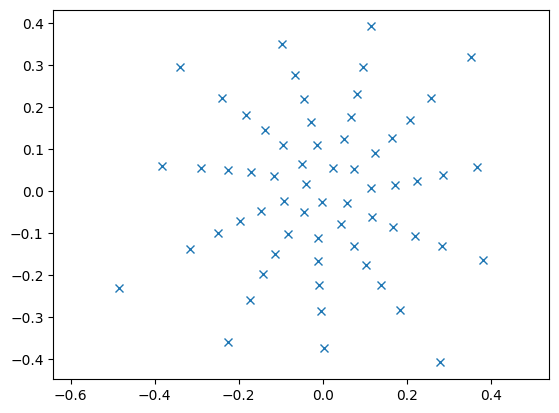

torch.Size([3, 64])


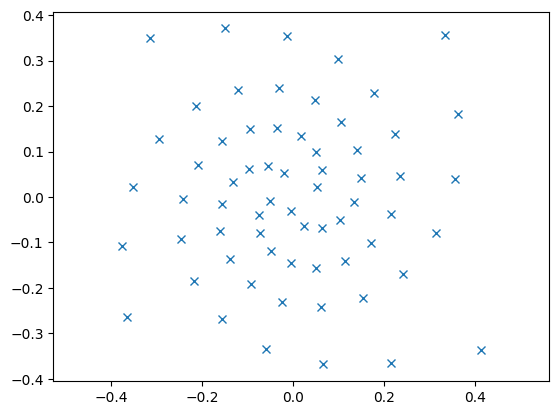

torch.Size([3, 64])


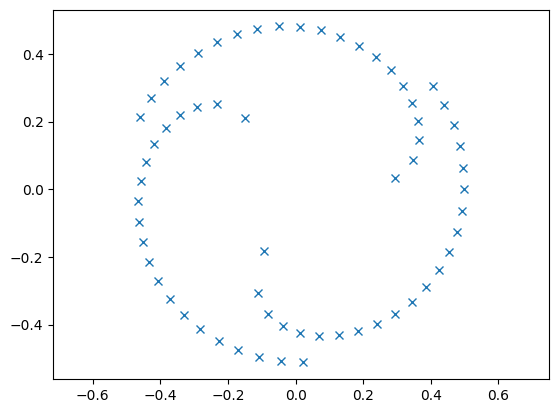

torch.Size([3, 64])


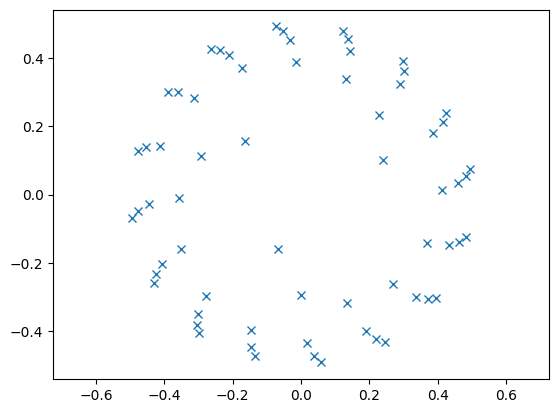

torch.Size([3, 64])


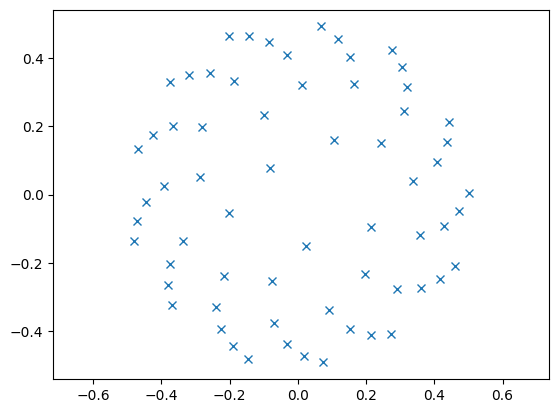

torch.Size([3, 64])


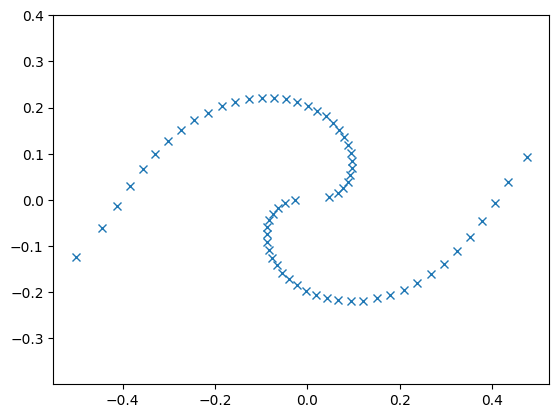

torch.Size([3, 64])


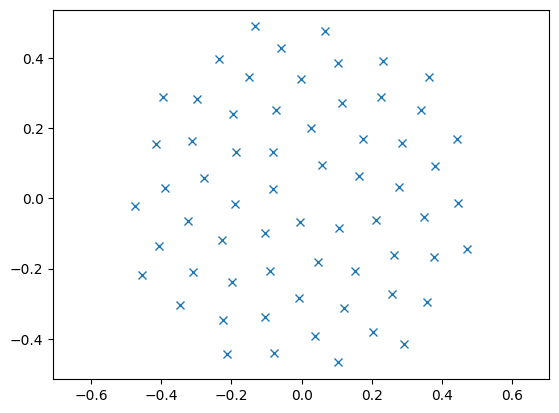


100%|██████████| 20/20 [00:05<00:00,  3.98it/s]

torch.Size([3, 64])


In [8]:
import torch
from scipy.spatial.distance import pdist


test_generator = np.random.default_rng(seed=20006)
config = VariableArrayConfig(mpos_fn=VogelHansenNew, mode="analytic", mic_sig_noise=False, generator=test_generator, min_nsources=1, max_nsources=4, min_num_mics=64, max_num_mics=64)

dataset = DatasetSynthetic(config=config)

dataset_generator = dataset.generate(
    #features=["loc","source_strength_analytic"], # choose the features to extract
    features = ["cartesian_coordinates"], # choose the features to extract
    f=[1000], # choose the frequencies to extract
    split='training', # choose the split of the dataset
    size=20, # choose the size of the dataset
    )


for data in dataset_generator:
    coords = torch.tensor(data["cartesian_coordinates"])
    plt.plot(coords[0,:], coords[1,:], "x")
    plt.axis('equal')
    plt.show()

    print(coords.shape)
        
        
        
        

In [4]:
 #coords = torch.tensor(data["cartesian_coordinates"])
        #plt.plot(coords[0,:], coords[1,:], "x")
        #plt.axis('equal')
        #plt.show()

        #print(coords.shape)

        #csm = torch.tensor(data["csm"])
        #print(csm)
        #print(data["idx"], "\n")
        #array = dataset.config.micgeom_sampler.target
        #coords = array.pos_total
        #print(array.center)
        #print(array.aperture)
        #plt.scatter(coords[0], coords[1])
        #plt.axis('equal')
        #plt.show()